In [1]:
%%capture
%pip install qldpc
%pip install matplotlib

## Sliding Window Decoding

We can make use of `decoders.SlidingWindowDecoder` to split a memory experiment into a sequence of decoding windows.  Here we give an example of using this for X and Z sliding window decoding of a surface code memory experiment. 

### imports, simulation, and plotting code

In [2]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter

from qldpc import circuits, codes, decoders

from common import get_label

%matplotlib inline

In [3]:
def run_combined_memory_experiments_with_sliding_window_decoder(
    codes_to_simulate: Sequence[codes.QuditCode],
    error_rates: Sequence[float] = list(np.logspace(-3, -2, 5)),
    num_windows: int = 5,
    max_shots: int = 10**5,
    max_errors: int = 100,
    distance_trials: int = 100,
    **decoding_kwargs: object,
) -> list[sinter.TaskStats]:
    """Use sinter to simulate memory cycles of the given codes and decoding using a sliding window decoder.

    This function ...
      1. Builds a memory experiment for each code.
      2. Adds a depolarizing noise to all gates, at the provided error rates.
      2. Wraps each noisy circuit in a `sinter.Task``.
      3. Runs batched Monte Carlo sampling with `sinter.collect`.

    Args:
        codes_to_simulate: The codes we wish to simulate.
        error_rates: The i.i.d. probabilities of a depolarizing error after each gate.
        num_windows: Number of windows in circuits. The number of rounds in each window is the code distance.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stops the sampling process after this many errors have been seen in samples
            taken from the circuit.
        distance_trials: If the code distance is not known, estimate it with this many trials.
            The estimated distance determines the number of rounds of syndrome measurement.
        **decoding_kwargs: Arguments to pass to the decoder.

    Returns:
        A `sinter` stats object aggregating shots, errors, and metadata for downstream plotting.
    """
    noise_models = {
        prob: circuits.DepolarizingNoiseModel(prob, include_idling_error=False)
        for prob in error_rates
    }

    tasks = []
    custom_decoders = {}  # each code is going to need its own decoder
    for code_index, code in enumerate(codes_to_simulate):
        distance = code.get_distance(bound=distance_trials)

        # Collect the components of the memory experiment.  In particular, we will need the record
        # of detectors and qubit indices.
        initialization, qec_cycle, readout, measurement_record, detector_record, qubit_ids = (
            circuits.get_memory_experiment_parts(
                code, basis=None, num_rounds=num_windows * distance
            )
        )

        # Identify detectors associated with X-type and Z-type stabilizers (parity checks).
        detectors_x = detector_record.get_events(*qubit_ids.checks_x)
        detectors_z = detector_record.get_events(*qubit_ids.checks_z)

        # Build a sliding window decoder for both X and Z decoding problems
        # The window size is chosen to be the code distance, and the stride is chosen to be half the distance
        # This also corresponds to a commit region of size half the distance.
        decoder = decoders.SlidingWindowDecoder(
            distance,
            distance // 2,
            (detectors_x, detectors_z),  # decode X/Z detectors independently
            **decoding_kwargs,
        )
        decoder_name = f"decoder_{code_index}"
        custom_decoders[decoder_name] = decoder

        for prob in error_rates:
            noise_model = noise_models[prob]
            noisy_circuit = initialization + noise_model.noisy_circuit(qec_cycle) + readout
            tasks.append(
                sinter.Task(
                    circuit=noisy_circuit,
                    decoder=decoder_name,
                    json_metadata={
                        "label": get_label(code),
                        "prob": prob,
                        "rounds": num_windows * distance,
                    },
                )
            )

    return sinter.collect(
        num_workers=os.cpu_count() - 2,
        max_shots=max_shots,
        max_errors=max_errors,
        tasks=tasks,
        custom_decoders=custom_decoders,
    )


def make_sliding_window_memory_experiment_figure(
    codes_to_simulate: Sequence[codes.QuditCode],
    error_rates: Sequence[float] = list(np.logspace(-3, -2, 5)),
    num_windows: int = 5,
    max_shots: int = 10**5,
    max_errors: int = 100,
    distance_trials: int = 100,
    figsize: tuple[int, int] = (5, 4),
    **decoding_kwargs: object,
) -> tuple[plt.Figure, plt.Axes]:
    """Use sinter to simulate memory cycles of the given codes, and plot the results.

    Args:
        codes_to_simulate: The codes we wish to simulate.
        error_rates: The i.i.d. probabilities of a depolarizing error after each gate.
        max_shots: Stop sampling the circuit after this many shots.
        num_windows: Number of windows in circuits. The number of rounds in each window is the code distance.
        max_errors: Stops the sampling process after this many errors have been seen in samples
            taken from the circuit.
        distance_trials: If the code distance is not known, estimate it with this many trials.
            The estimated distance determines the number of rounds of syndrome measurement.
        figsize: The size of the figure to produce.
        **decoding_kwargs: Arguments to pass to the decoder.

    Returns:
        The matplotlib.pyplot figure and axis.
    """
    stats = run_combined_memory_experiments_with_sliding_window_decoder(
        codes_to_simulate,
        error_rates,
        num_windows,
        max_shots,
        max_errors,
        distance_trials,
        **decoding_kwargs,
    )

    figure, axis = plt.subplots(figsize=figsize)
    sinter.plot_error_rate(
        ax=axis,
        stats=stats,
        x_func=lambda stats: stats.json_metadata["prob"],
        group_func=lambda stats: stats.json_metadata["label"],
        failure_units_per_shot_func=lambda stats: stats.json_metadata["rounds"],
    )

    axis.axline(
        (0, 0),
        slope=1,
        color="k",
        linestyle=":",
        label=r"$p_{\mathrm{log}}=p_{\mathrm{phys}}$",
    )
    axis.loglog()
    axis.set_xlabel(r"physical error rate")
    axis.set_ylabel(r"Logical error rate per round")
    axis.legend(loc="best")
    axis.grid(which="both")
    figure.tight_layout()

    return figure, axis


def logical_error_rate_saturation_experiment(
    codes_to_simulate: Sequence[codes.QuditCode],
    error_rate: float = 3e-3,
    num_rounds_list: Sequence[int] = range(1, 25, 2),
    max_shots: int = 10**5,
    max_errors: int = 100,
    distance_trials: int = 100,
    **decoding_kwargs: object,
) -> list[sinter.TaskStats]:
    """Use sinter to simulate logical error rate per round with sliding window decoder for an increasing number of rounds.

    This function ...
      1. Builds a memory experiment for each code.
      2. Adds a depolarizing noise to all gates, at the provided error rate.
      2. Wraps each noisy circuit in a `sinter.Task``.
      3. Runs batched Monte Carlo sampling with `sinter.collect`.

    Args:
        codes_to_simulate: The codes we wish to simulate.
        error_rates: The i.i.d. probability of a depolarizing error after each gate.
        num_rounds_list: Sequence of an increasing number of rounds used in experiments.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stops the sampling process after this many errors have been seen in samples
            taken from the circuit.
        distance_trials: If the code distance is not known, estimate it with this many trials.
            The estimated distance determines the number of rounds of syndrome measurement.
        **decoding_kwargs: Arguments to pass to the decoder.

    Returns:
        A `sinter` stats object aggregating shots, errors, and metadata for downstream plotting.
    """
    noise_model = circuits.DepolarizingNoiseModel(error_rate, include_idling_error=False)

    tasks = []
    custom_decoders = {}  # each code is going to need its own decoder
    for code_index, code in enumerate(codes_to_simulate):
        distance = code.get_distance(bound=distance_trials)

        for num_rounds in num_rounds_list:
            # Collect the components of the memory experiment.  In particular, we will need the record
            # of detectors and qubit indices.
            initialization, qec_cycle, readout, measurement_record, detector_record, qubit_ids = (
                circuits.get_memory_experiment_parts(code, basis=None, num_rounds=num_rounds)
            )

            # Identify detectors associated with X-type and Z-type stabilizers (parity checks).
            detectors_x = detector_record.get_events(*qubit_ids.checks_x)
            detectors_z = detector_record.get_events(*qubit_ids.checks_z)

            # Build a sliding window decoder for both X and Z decoding problems
            # The window size is chosen to be the code distance, and the stride is chosen to be half the distance
            # This also corresponds to a commit region of size half the distance.
            decoder = decoders.SlidingWindowDecoder(
                distance,
                distance // 2,
                (detectors_x, detectors_z),  # decode X/Z detectors independently
                **decoding_kwargs,
            )
            decoder_name = f"decoder_{code_index}_{num_rounds}"
            custom_decoders[decoder_name] = decoder

            noisy_circuit = initialization + noise_model.noisy_circuit(qec_cycle) + readout
            tasks.append(
                sinter.Task(
                    circuit=noisy_circuit,
                    decoder=decoder_name,
                    json_metadata={
                        "label": get_label(code),
                        "prob": error_rate,
                        "rounds": num_rounds,
                    },
                )
            )

    return sinter.collect(
        num_workers=os.cpu_count() - 2,
        max_shots=max_shots,
        max_errors=max_errors,
        tasks=tasks,
        custom_decoders=custom_decoders,
    )


def make_logical_error_rate_saturation_experiment_figure(
    codes_to_simulate: Sequence[codes.QuditCode],
    error_rate: float = 3e-3,
    num_rounds_list: Sequence[int] = list(range(1, 25, 1)),
    max_shots: int = 10**5,
    max_errors: int = 100,
    distance_trials: int = 100,
    figsize: tuple[int, int] = (5, 4),
    **decoding_kwargs: object,
) -> tuple[plt.Figure, plt.Axes]:
    """Use sinter to simulate memory cycles of the given codes, and plot the results.

    Args:
        codes_to_simulate: The codes we wish to simulate.
        error_rates: The i.i.d. probability of a depolarizing error after each gate.
        num_rounds_list: Sequence of an increasing number of rounds used in experiments.
        max_shots: Stop sampling the circuit after this many shots.
        max_errors: Stops the sampling process after this many errors have been seen in samples
            taken from the circuit.
        distance_trials: If the code distance is not known, estimate it with this many trials.
            The estimated distance determines the number of rounds of syndrome measurement.
        figsize: The size of the figure to produce.
        **decoding_kwargs: Arguments to pass to the decoder.

    Returns:
        The matplotlib.pyplot figure and axis.
    """
    stats = logical_error_rate_saturation_experiment(
        codes_to_simulate,
        error_rate,
        num_rounds_list,
        max_shots,
        max_errors,
        distance_trials,
        **decoding_kwargs,
    )

    figsize: tuple[int, int] = (5, 4)
    figure, axis = plt.subplots(figsize=figsize)

    sinter.plot_error_rate(
        ax=axis,
        stats=stats,
        x_func=lambda stats: stats.json_metadata["rounds"],
        group_func=lambda stats: stats.json_metadata["label"],
        failure_units_per_shot_func=lambda stats: stats.json_metadata["rounds"],
    )

    axis.set_yscale("log")
    axis.set_xlabel(r"number of rounds")
    axis.set_ylabel(r"logical error rate per round")
    axis.legend(loc="best")
    axis.grid(which="both")
    figure.tight_layout()

    return figure, axis

### Surface code

Since our experiment involves multiple measurement rounds, we opt to plot the logical error rate per round.

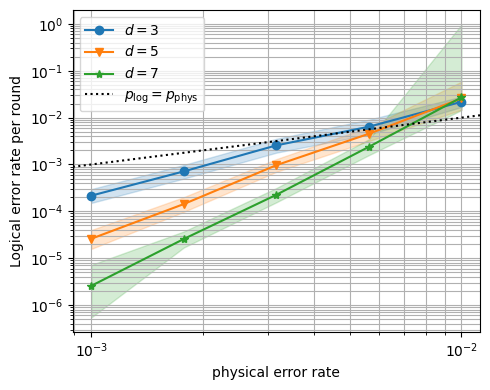

In [4]:
codes_to_simulate = [codes.SurfaceCode(dist, rotated=True) for dist in (3, 5, 7)]
make_sliding_window_memory_experiment_figure(codes_to_simulate, with_MWPM=True)
plt.show()

We can also show the logical error rate per round is constant when using a window of size $d$.

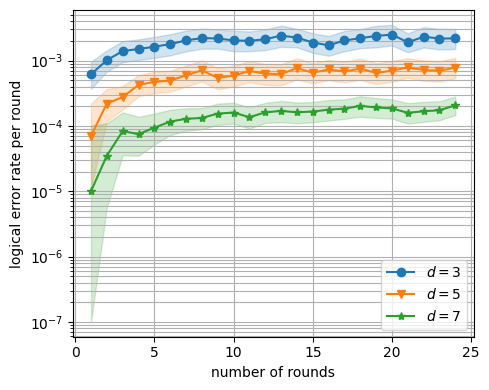

In [5]:
make_logical_error_rate_saturation_experiment_figure(codes_to_simulate, with_MWPM=True)
plt.show()